(16598, 11)
   Rank             Name Platform    Year     Genre   Publisher  NA_Sales  \
0   259        Asteroids     2600  1980.0   Shooter       Atari      4.00   
1   545  Missile Command     2600  1980.0   Shooter       Atari      2.56   
2  1768          Kaboom!     2600  1980.0      Misc  Activision      1.07   
3  1971         Defender     2600  1980.0      Misc       Atari      0.99   
4  2671           Boxing     2600  1980.0  Fighting  Activision      0.72   

   EU_Sales  JP_Sales  Other_Sales  Global_Sales  
0      0.26       0.0         0.05          4.31  
1      0.17       0.0         0.03          2.76  
2      0.07       0.0         0.01          1.15  
3      0.05       0.0         0.01          1.05  
4      0.04       0.0         0.01          0.77  
Rank              int64
Name                str
Platform            str
Year            float64
Genre               str
Publisher           str
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Oth

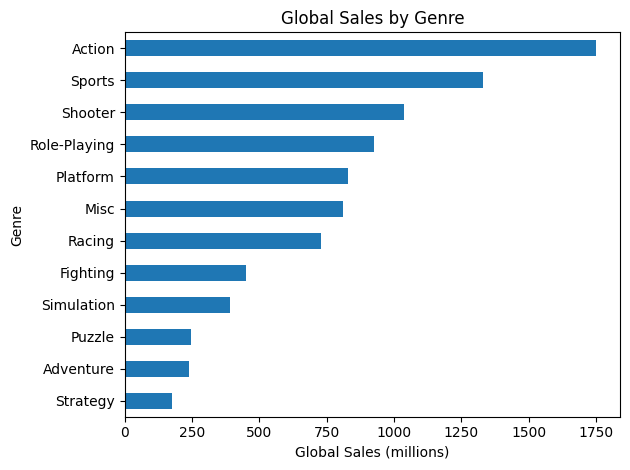

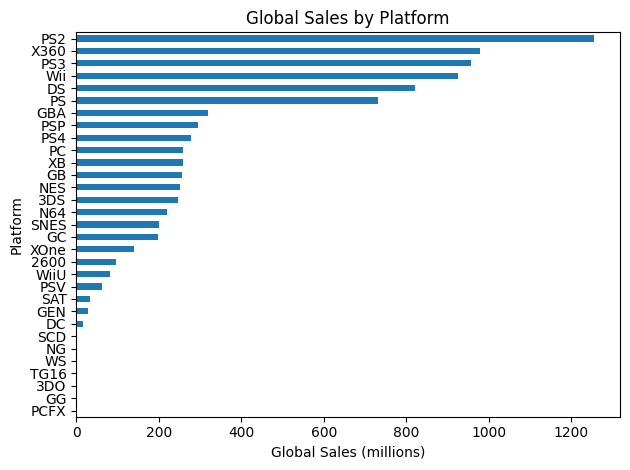

<Figure size 640x480 with 0 Axes>

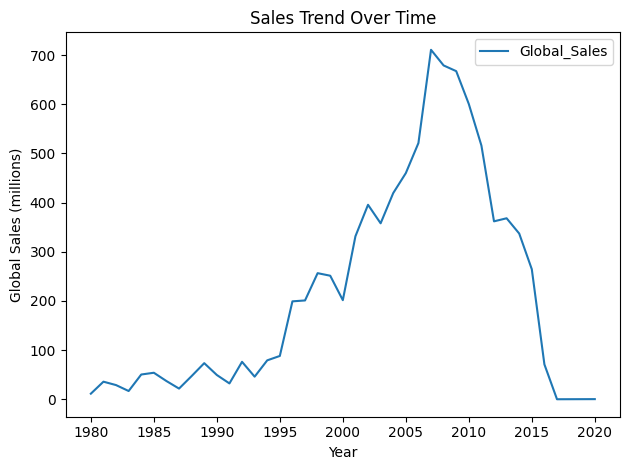

<Figure size 640x480 with 0 Axes>

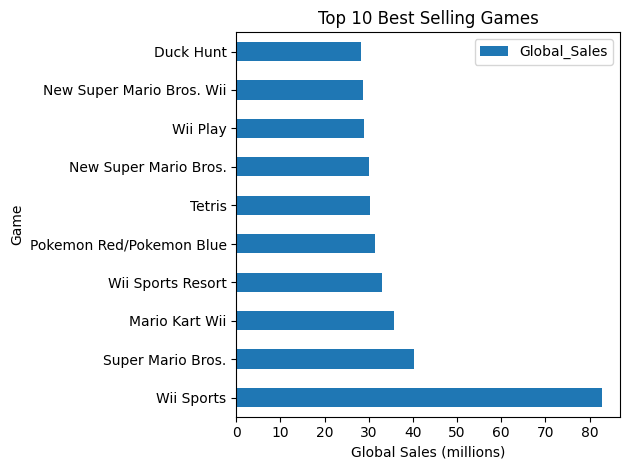

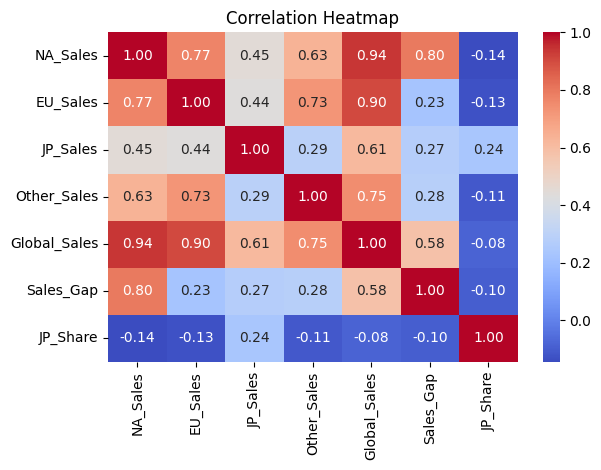

In [ ]:

# ========== Preprocessing Data ========== 
# Loading data
import pandas as pd

df = pd.read_csv("vgsales new.csv")

print(df.shape)
print(df.head())

# Data type conversion
df["Name"] = df["Name"].str.strip()
df["Platform"] = df["Platform"].str.strip()
df["Genre"] = df["Genre"].str.strip()
df["Publisher"] = df["Publisher"].str.strip()

print(df.dtypes)

# Missing values
print(df.isnull().sum())

df["Year"] = df["Year"].fillna(df["Year"].median())
df["Publisher"] = df["Publisher"].fillna("Unknown")

print(df.isnull().sum())

df["Year"] = df["Year"].astype(int)

print(df.dtypes)

# Duplicates
print(df.duplicated().sum())
print(df.duplicated(subset=["Name", "Platform"]).sum())

df.drop_duplicates(subset=["Name", "Platform"], keep="first", inplace=True)

print(df.shape) 

# Outlier detection
Q1 = df["Global_Sales"].quantile(0.25)
Q3 = df["Global_Sales"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(Q1)
print(Q3)
print(IQR)

outliers = df[(df["Global_Sales"] < lower_bound) |
              (df["Global_Sales"] > upper_bound)]

print(len(outliers))

df["Sales_Outlier_Flag"] = (
    (df["Global_Sales"] < lower_bound) | (df["Global_Sales"] > upper_bound)).astype(int)

print(df["Sales_Outlier_Flag"].value_counts())

# Feature engineering
df["Sales_Gap"] = (df["NA_Sales"] - df["EU_Sales"])
df["JP_Share"] = ((df["JP_Sales"] / df["Global_Sales"]) * 100) .round(2)
df["Genre_Encoded"] = df["Genre"].astype("category").cat.codes
df["Platform_Encoded"] = df["Platform"].astype("category").cat.codes

print(df.head())

# Final validation
print(df.shape)
print(df.isnull().sum().sum())
df.to_csv("cleaned_vgsales.csv", index=False)

# ========== EDA ========== 

# Loading cleaned data and imports
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("cleaned_vgsales.csv")
print(df.shape)

# Global Sales by Genre
plt.figure()
genre_sales = df.groupby("Genre")["Global_Sales"].sum().sort_values()
genre_sales.plot(kind="barh")
plt.title("Global Sales by Genre")
plt.xlabel("Global Sales (millions)")
plt.ylabel("Genre")
plt.tight_layout()

# Global Sales by Platform
plt.figure()
platform_sales = df.groupby("Platform")["Global_Sales"].sum().sort_values()
platform_sales.plot(kind="barh")
plt.title("Global Sales by Platform")
plt.xlabel("Global Sales (millions)")
plt.ylabel("Platform")
plt.tight_layout()

# Sales Trend Over Time
plt.figure()
global_sales = df.groupby(["Year"])["Global_Sales"].sum().reset_index()
global_sales.plot(kind="line", x="Year", y="Global_Sales")
plt.title("Sales Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Global Sales (millions)")
plt.tight_layout()

# Top 10 Best Selling Games
plt.figure()
top10 = df.nlargest(10, "Global_Sales")
top10.plot(kind="barh", x="Name", y="Global_Sales")
plt.title("Top 10 Best Selling Games")
plt.xlabel("Global Sales (millions)")
plt.ylabel("Game")
plt.tight_layout()

# Correlation Heatmap
plt.figure()
corr = df[["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales", "Global_Sales", "Sales_Gap", "JP_Share"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()

# ========== PySpark Processing ==========

# # Starting Spark Session
# from pyspark.sql import SparkSession
# spark = SparkSession.builder.appName("VideoGameSales").getOrCreate()
# print(spark)

In [11]:
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("VideoGameSales") \
    .master("local") \
    .getOrCreate()
print(spark)

KeyboardInterrupt: 